In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

# Cargar datos
carros = pd.read_csv("carros.csv")

 


[136184.] [6048.]
[1385956.] [509718.]


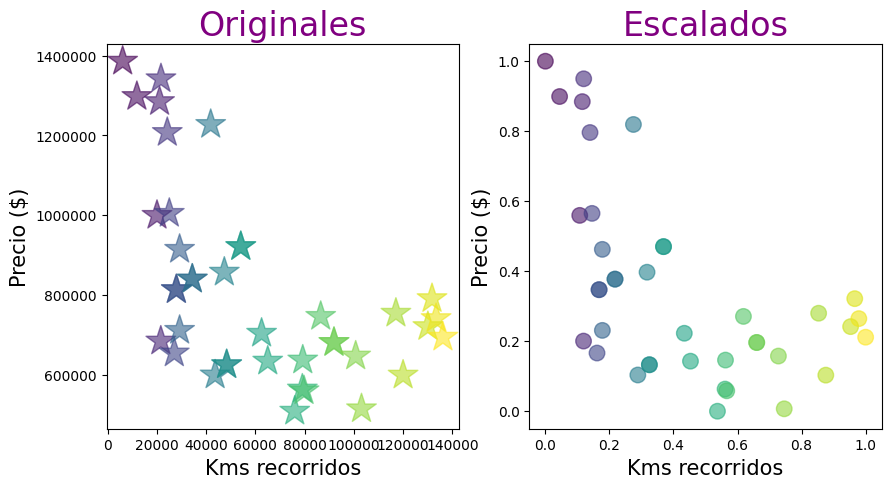

[[0.        ]
 [0.04439202]
 [0.10721092]
 [0.11526403]
 [0.11911385]
 [0.11960564]
 [0.1393619 ]
 [0.14563226]
 [0.16120827]
 [0.16763232]
 [0.16763232]
 [0.17782166]
 [0.17788314]
 [0.21740333]
 [0.21740333]
 [0.27493545]
 [0.28865956]
 [0.31742177]
 [0.32476794]
 [0.32476794]
 [0.36886027]
 [0.36886027]
 [0.43380002]
 [0.45303375]
 [0.53729176]
 [0.56104383]
 [0.56238089]
 [0.56629219]
 [0.61843763]
 [0.65985584]
 [0.65985584]
 [0.72764646]
 [0.74575828]
 [0.85323047]
 [0.87564548]
 [0.9530568 ]
 [0.96598174]
 [0.97873763]
 [1.        ]] [[1.        ]
 [0.89914384]
 [0.55953063]
 [0.88460669]
 [0.20038163]
 [0.94983555]
 [0.79632018]
 [0.56523684]
 [0.16626076]
 [0.34725953]
 [0.34725953]
 [0.46245198]
 [0.23093726]
 [0.37738834]
 [0.37738834]
 [0.81927741]
 [0.10351754]
 [0.39717291]
 [0.1328178 ]
 [0.1328178 ]
 [0.47028547]
 [0.47028547]
 [0.22270547]
 [0.14297714]
 [0.        ]
 [0.06327048]
 [0.14612468]
 [0.05834944]
 [0.27088302]
 [0.19633935]
 [0.19633935]
 [0.15759873]
 [0.0

In [ ]:
# Graficar datos crudos: kms vs precio
# Graficar datos crudos: kms vs precio
fig = plt.figure(figsize=(10, 5))

ax = fig.add_subplot(1, 2, 1)

ax.scatter(carros["kms"], carros["precio"], marker="*",
           s=500, c=range(carros["kms"].size), alpha=0.6)

ax.set_title("Originales", size=24, color="purple")
ax.set_ylabel("Precio ($)", size=15)
ax.set_xlabel("Kms recorridos", size=15)
ax.ticklabel_format(style="plain")
# Escalamiento de los datos
escala_kms = preprocessing.MinMaxScaler()
escala_precio = preprocessing.MinMaxScaler()
kms = escala_kms.fit_transform(carros["kms"].values.reshape(-1, 1))
precio = escala_precio.fit_transform(carros["precio"].values.reshape(-1, 1))
print(escala_kms.data_max_, escala_kms.data_min_)
print(escala_precio.data_max_, escala_precio.data_min_)
# Graficar datos escalados: kms vs precio
ax = fig.add_subplot(1, 2, 2)

ax.scatter(kms, precio, marker=".",
           s=500, c=range(kms.size), alpha=0.6)

ax.set_title("Escalados", size=24, color="purple")
ax.set_ylabel("Precio ($)", size=15)
ax.set_xlabel("Kms recorridos", size=15)
ax.ticklabel_format(style="plain")

plt.show()



In [28]:
# Escalamiento de los datos
escala_kms = preprocessing.MinMaxScaler()
escala_precio = preprocessing.MinMaxScaler()
kms = escala_kms.fit_transform(carros["kms"].values.reshape(-1, 1))
precio = escala_precio.fit_transform(carros["precio"].values.reshape(-1, 1))
print(escala_kms.data_max_, escala_kms.data_min_)
print(escala_precio.data_max_, escala_precio.data_min_)


[136184.] [6048.]
[1385956.] [509718.]


In [29]:
# Graficar datos escalados: kms vs precio
ax = fig.add_subplot(1, 2, 2)

ax.scatter(kms, precio, marker="*",
           s=500, c=range(kms.size), alpha=0.6)

ax.set_title("Escalados", size=24, color="purple")
ax.set_ylabel("Precio ($)", size=15)
ax.set_xlabel("Kms recorridos", size=15)
ax.ticklabel_format(style="plain")

plt.show()


In [30]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(kms, precio)
# Predecir el precio de un carro con 20000 kms
knn_instancia = escala_kms.transform([[76000]])
# Predecir el precio de un carro con 20000 kms
precio_instancia = knn.predict(knn_instancia)
# Desescalar el precio predicho
escala_precio.inverse_transform(precio_instancia)


array([[570878.]])

In [31]:
#precios de carros de 0 a 140000 kms
kms_instancia = escala_kms.transform(np.arange(140000).reshape(-1, 1))
precio_instancia= knn.predict(kms_instancia)
todas = escala_precio.inverse_transform(precio_instancia)
todas =todas.reshape(1,-1)
print(todas)

[[1227846.         1227846.         1227846.         ...  742707.33333333
   742707.33333333  742707.33333333]]


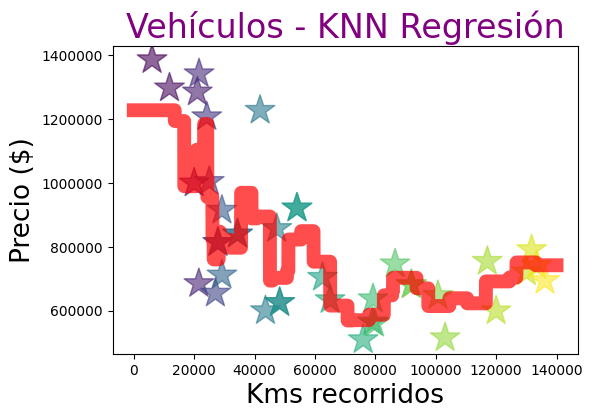

In [32]:
# Graficar los resultados de las múltiples regresiones
fig = plt.figure(figsize=(6, 4))

plt.plot(np.arange(140000), todas.reshape(1, -1)[0],
         linewidth=10, color="red", alpha=0.7)

plt.scatter(carros["kms"], carros["precio"], marker="*",
            s=500, c=range(carros["kms"].size), alpha=0.6)

plt.title("Vehículos - KNN Regresión", size=24, color="purple")
plt.ylabel("Precio ($)", size=19)
plt.xlabel("Kms recorridos", size=19)
plt.ticklabel_format(style="plain")
plt.show()